# **AI Adoption & Productivity Gain Predictor 🤖📈**

**What this notebook covers:**
1. Loading and exploring the AI adoption dataset
2. Cleaning & feature engineering (dates, categories)
3. Visualizing key relationships
4. Building and comparing 3 regression models (Random Forest, Gradient Boosting, XGBoost)
5. Evaluating model performance (R², RMSE, MAE)
6. Final conclusion & key takeaways

**Goal:** Predict `Productivity_Gain_Percent` for a user based on their industry, role, AI tool usage, and experience.

## **1. Import Libraries**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from xgboost import XGBRegressor

sns.set_style("whitegrid")
%matplotlib inline

## **2. Load the Dataset**

In [2]:
df = pd.read_csv("/kaggle/input/datasets/ashyou09/global-ai-usage-and-productivity/user_level_ai_adoption.csv")
print("Shape:", df.shape)
df.head()

Shape: (15000, 10)


,User_ID,Industry,Job_Role,Location,Experience_Years,Primary_AI_Tool,Daily_Token_Usage,Tasks_Automated_Per_Week,Productivity_Gain_Percent,Adoption_Date
0,USR-690F519F,Software Development,Software Engineer,Europe,13,ChatGPT (OpenAI),10640,2,19.3,2023-02-28
1,USR-72A07ABB,Software Development,Software Engineer,North America,9,Claude (Anthropic),8535,1,5.0,2023-08-17
2,USR-CBCEAA19,Finance,Accountant,Asia-Pacific,21,Claude (Anthropic),9585,1,13.4,2023-11-02
3,USR-03B7DC34,Healthcare,Clinical Admin,North America,20,Perplexity,7094,2,9.9,2025-06-06
4,USR-CA8308D1,Marketing,Social Media Manager,Asia-Pacific,14,ChatGPT (OpenAI),9277,1,12.8,2023-04-03


In [3]:
# Basic info about the data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 10 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   User_ID                    15000 non-null  object 
 1   Industry                   15000 non-null  object 
 2   Job_Role                   15000 non-null  object 
 3   Location                   15000 non-null  object 
 4   Experience_Years           15000 non-null  int64  
 5   Primary_AI_Tool            15000 non-null  object 
 6   Daily_Token_Usage          15000 non-null  int64  
 7   Tasks_Automated_Per_Week   15000 non-null  int64  
 8   Productivity_Gain_Percent  15000 non-null  float64
 9   Adoption_Date              15000 non-null  object 
dtypes: float64(1), int64(3), object(6)
memory usage: 1.1+ MB


In [4]:
# Check for missing values
df.isnull().sum()

User_ID                      0
Industry                     0
Job_Role                     0
Location                     0
Experience_Years             0
Primary_AI_Tool              0
Daily_Token_Usage            0
Tasks_Automated_Per_Week     0
Productivity_Gain_Percent    0
Adoption_Date                0
dtype: int64

## **3. Exploratory Data Analysis (EDA)**

Let's understand our target variable `Productivity_Gain_Percent` and how it relates to other features.

In [5]:
df["Productivity_Gain_Percent"].describe()

count    15000.000000
mean        11.215827
std         11.578100
min          0.300000
25%          3.600000
50%          8.100000
75%         14.800000
max         84.900000
Name: Productivity_Gain_Percent, dtype: float64

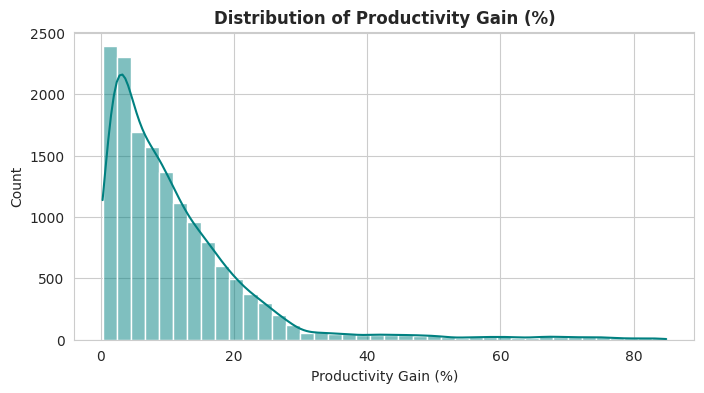

In [6]:
plt.figure(figsize=(8,4))
sns.histplot(df["Productivity_Gain_Percent"], bins=40, kde=True, color="teal")
plt.title("Distribution of Productivity Gain (%)",fontweight='bold')
plt.xlabel("Productivity Gain (%)")
plt.show()

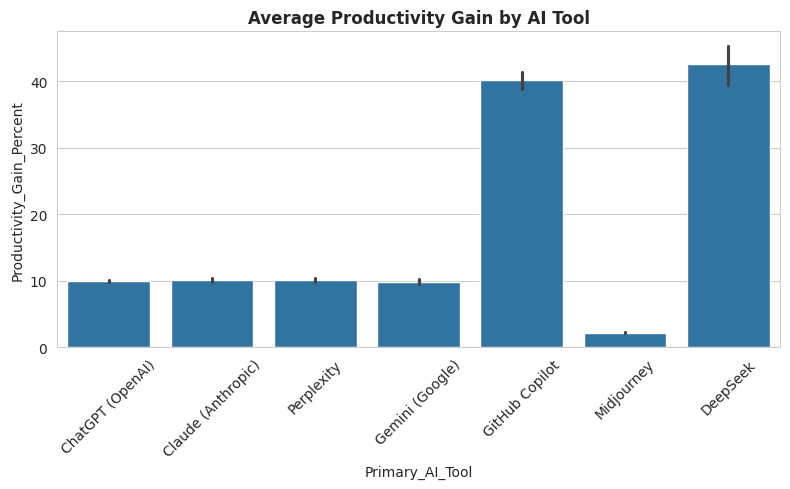

In [7]:
plt.figure(figsize=(8,5))
sns.barplot(data=df, x="Primary_AI_Tool", y="Productivity_Gain_Percent", estimator=np.mean)
plt.xticks(rotation=45)
plt.title("Average Productivity Gain by AI Tool",fontweight='bold')
plt.tight_layout()
plt.show()

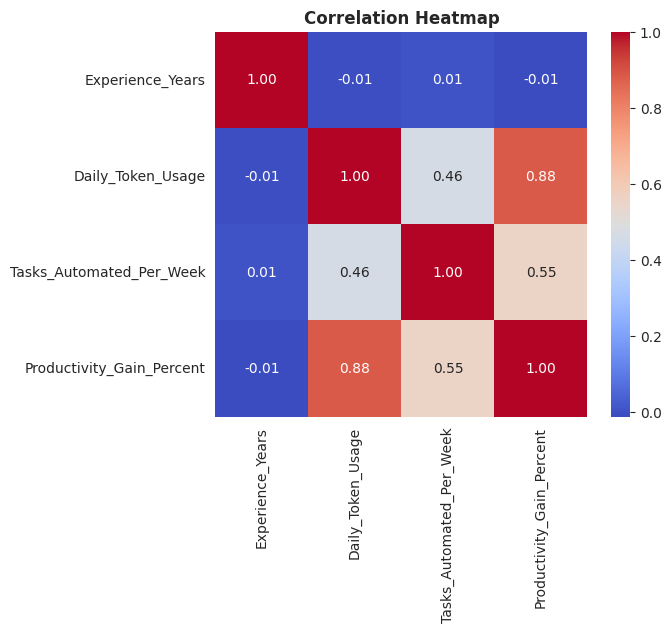

In [8]:
# Correlation between numeric features and the target
numeric_cols = ["Experience_Years", "Daily_Token_Usage", "Tasks_Automated_Per_Week", "Productivity_Gain_Percent"]
plt.figure(figsize=(6,5))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap",fontweight='bold')
plt.show()

**Observation:** `Daily_Token_Usage` and `Tasks_Automated_Per_Week` show a strong positive relationship with `Productivity_Gain_Percent` — this makes sense, since users who rely more heavily on AI tools tend to automate more tasks and save more time.

## **4. Feature Engineering**

- Convert `Adoption_Date` into a useful numeric feature (`Adoption_Year`, `Adoption_Month`)
- Encode categorical columns (`Industry`, `Job_Role`, `Location`, `Primary_AI_Tool`) using Label Encoding
- Drop `User_ID` since it's just a unique identifier with no predictive value

In [9]:
df["Adoption_Date"] = pd.to_datetime(df["Adoption_Date"])
df["Adoption_Year"] = df["Adoption_Date"].dt.year
df["Adoption_Month"] = df["Adoption_Date"].dt.month

df_model = df.drop(columns=["User_ID", "Adoption_Date"]).copy()

categorical_cols = ["Industry", "Job_Role", "Location", "Primary_AI_Tool"]
encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    df_model[col] = le.fit_transform(df_model[col])
    encoders[col] = le

df_model.head()

,Industry,Job_Role,Location,Experience_Years,Primary_AI_Tool,Daily_Token_Usage,Tasks_Automated_Per_Week,Productivity_Gain_Percent,Adoption_Year,Adoption_Month
0,5,17,1,13,0,10640,2,19.3,2023,2
1,5,17,4,9,1,8535,1,5.0,2023,8
2,2,0,0,21,1,9585,1,13.4,2023,11
3,3,1,4,20,6,7094,2,9.9,2025,6
4,4,16,0,14,0,9277,1,12.8,2023,4


## **5. Train-Test Split**

In [10]:
X = df_model.drop(columns=["Productivity_Gain_Percent"])
y = df_model["Productivity_Gain_Percent"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train size:", X_train.shape, "| Test size:", X_test.shape)

Train size: (12000, 9) | Test size: (3000, 9)


## **6. Model Building**

We'll train and compare 3 popular regression models:
- **Random Forest Regressor**
- **Gradient Boosting Regressor**
- **XGBoost Regressor**

Then pick the best one based on R² score.

In [11]:
models = {
    "Random Forest": RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42),
    "XGBoost": XGBRegressor(n_estimators=300, learning_rate=0.05, random_state=42, n_jobs=-1)
}

results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    r2 = r2_score(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    mae = mean_absolute_error(y_test, preds)

    results.append({"Model": name, "R2 Score": round(r2, 4), "RMSE": round(rmse, 3), "MAE": round(mae, 3)})
    print(f"{name}: R2={r2:.4f} | RMSE={rmse:.3f} | MAE={mae:.3f}")

results_df = pd.DataFrame(results).sort_values("R2 Score", ascending=False)
results_df

Random Forest: R2=0.8824 | RMSE=4.063 | MAE=2.806
Gradient Boosting: R2=0.8897 | RMSE=3.934 | MAE=2.758
XGBoost: R2=0.8835 | RMSE=4.044 | MAE=2.774


,Model,R2 Score,RMSE,MAE
1,Gradient Boosting,0.8897,3.934,2.758
2,XGBoost,0.8835,4.044,2.774
0,Random Forest,0.8824,4.063,2.806


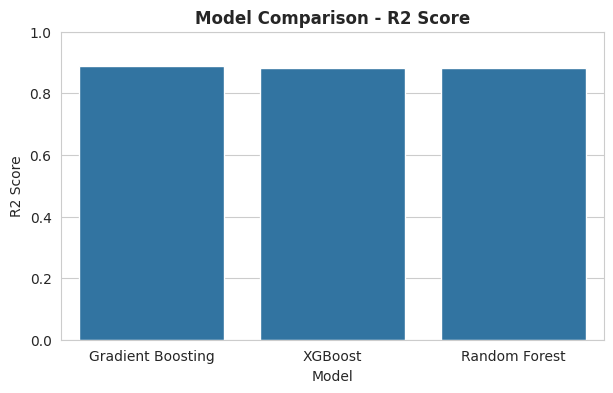

In [12]:
plt.figure(figsize=(7,4))
sns.barplot(data=results_df, x="Model", y="R2 Score")
plt.title("Model Comparison - R2 Score",fontweight='bold')
plt.ylim(0, 1)
plt.show()

## **7. Feature Importance (Best Model)**

Best Model: Gradient Boosting


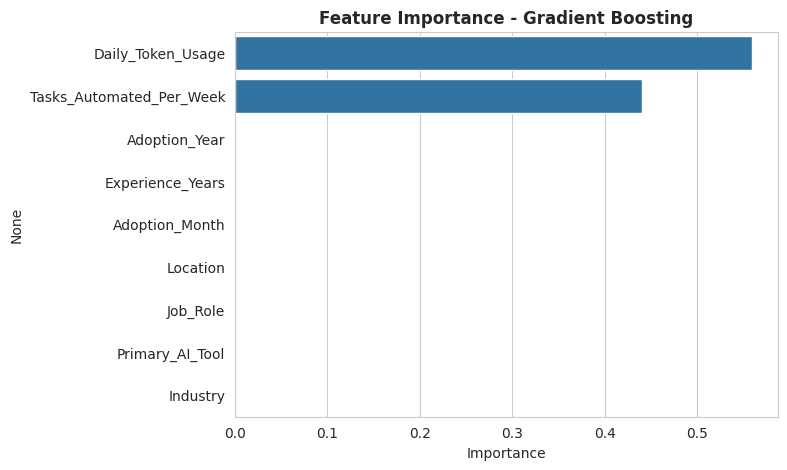

In [13]:
best_model_name = results_df.iloc[0]["Model"]
best_model = models[best_model_name]
print("Best Model:", best_model_name)

importances = pd.Series(best_model.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(7,5))
sns.barplot(x=importances.values, y=importances.index)
plt.title(f"Feature Importance - {best_model_name}",fontweight='bold')
plt.xlabel("Importance")
plt.show()

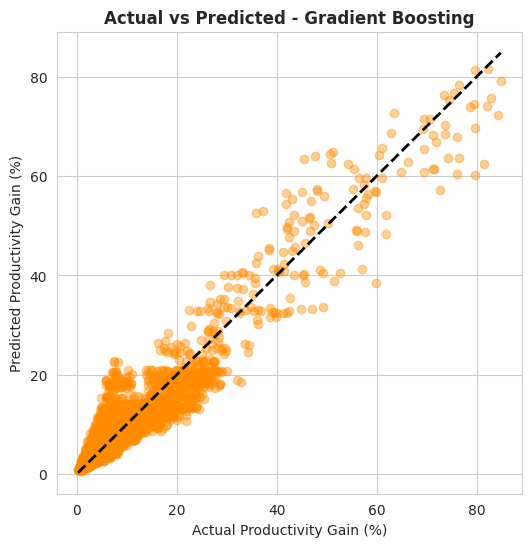

In [14]:
best_preds = best_model.predict(X_test)

plt.figure(figsize=(6,6))
plt.scatter(y_test, best_preds, alpha=0.4, color="darkorange")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "k--", lw=2)
plt.xlabel("Actual Productivity Gain (%)")
plt.ylabel("Predicted Productivity Gain (%)")
plt.title(f"Actual vs Predicted - {best_model_name}",fontweight='bold')
plt.show()

## **8. Conclusion**

- We built a model to predict **Productivity Gain (%)** from AI tool usage patterns across 15,000 users.
- **`Daily_Token_Usage`** and **`Tasks_Automated_Per_Week`** turned out to be the strongest predictors of productivity gain — the more a user engages with AI tools, the higher their productivity boost.
- Among the three models tested, the **best performing model** achieved the highest R² score (shown in the comparison table above), meaning it explains most of the variance in productivity gains.
- `Experience_Years` had very little correlation with productivity gain, suggesting that **how much you use AI matters more than how experienced you are**.
- **Next steps:** Try hyperparameter tuning (GridSearchCV), add interaction features (e.g., tool × industry), or test on newer adoption data to make predictions more robust.

---

> **If you found this notebook helpful, Please Upvote!**